# ARC Cluster Inspector

Displays all tasks in a cluster: training pair grids (input → output),
the LLM-generated description, and your own description (if annotated).

**Usage:** Run cells 1–3 once, then change `CLUSTER` in cell 3 and re-run cells 3 and 4.


In [1]:
%matplotlib inline
import json, re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ARC 10-colour palette
ARC_COLORS = ['#000000','#0074D9','#FF4136','#2ECC40','#FFDC00',
               '#AAAAAA','#F012BE','#FF851B','#7FDBFF','#870C25']
CMAP = mcolors.ListedColormap(ARC_COLORS)
NORM = mcolors.BoundaryNorm(range(11), CMAP.N)

def _find_project_root() -> Path:
    p = Path.cwd()
    for _ in range(8):
        if (p / 'data' / 'training').exists():
            return p
        if (p / 'CLAUDE.md').exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        'Cannot find project root. '
        'Run: jupyter notebook from inside the arc-agi-solver directory.'
    )

PROJECT = _find_project_root()
print(f'Project root: {PROJECT}')

# Load human descriptions (from annotate_tasks.ipynb)
desc_file = PROJECT / 'data' / 'human_descriptions.json'
human_descs = json.loads(desc_file.read_text()) if desc_file.exists() else {}
print(f'Human descriptions: {len(human_descs)} annotated')


Project root: /Users/rodhyde/Documents/GitHub/arc-agi-solver


In [2]:
def parse_inspection(path: Path) -> dict:
    """Parse cluster_inspection.txt into {cluster_id: {task_id: description}}."""
    text = path.read_text()
    result = {}

    # Each cluster block: header line, then task entries until next header or EOF
    cluster_pat = re.compile(
        r'={60}\nCluster (\d+) \(n=\d+\)\n={60}\n(.*?)(?=\n={60}\nCluster |\Z)',
        re.DOTALL,
    )
    task_pat = re.compile(
        r'  ([0-9a-f]{8}):\n(.*?)(?=\n  [0-9a-f]{8}:|\Z)',
        re.DOTALL,
    )

    for m in cluster_pat.finditer(text):
        cid   = int(m.group(1))
        body  = m.group(2)
        tasks = {}
        for tm in task_pat.finditer(body):
            tasks[tm.group(1)] = tm.group(2).strip()
        result[cid] = tasks

    return result

cluster_data = parse_inspection(PROJECT / 'results' / 'cluster_inspection.txt')
print(f"Parsed {len(cluster_data)} clusters: {sorted(cluster_data.keys())}")

Parsed 29 clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


In [3]:
# ── Change CLUSTER to inspect a different cluster ────────────────────────
CLUSTER = 9

task_desc = cluster_data[CLUSTER]
task_ids  = sorted(task_desc.keys())

tasks = {}
for tid in task_ids:
    p = PROJECT / 'data' / 'training' / f'{tid}.json'
    if p.exists():
        tasks[tid] = json.loads(p.read_text())
    else:
        print(f'  Warning: {tid}.json not found')

print(f'Cluster {CLUSTER}: {len(tasks)} / {len(task_ids)} tasks loaded')

Cluster 9: 24 / 24 tasks loaded



──────────────────────────────────────────────────────────────
  234bbc79   (4 training pairs)
──────────────────────────────────────────────────────────────


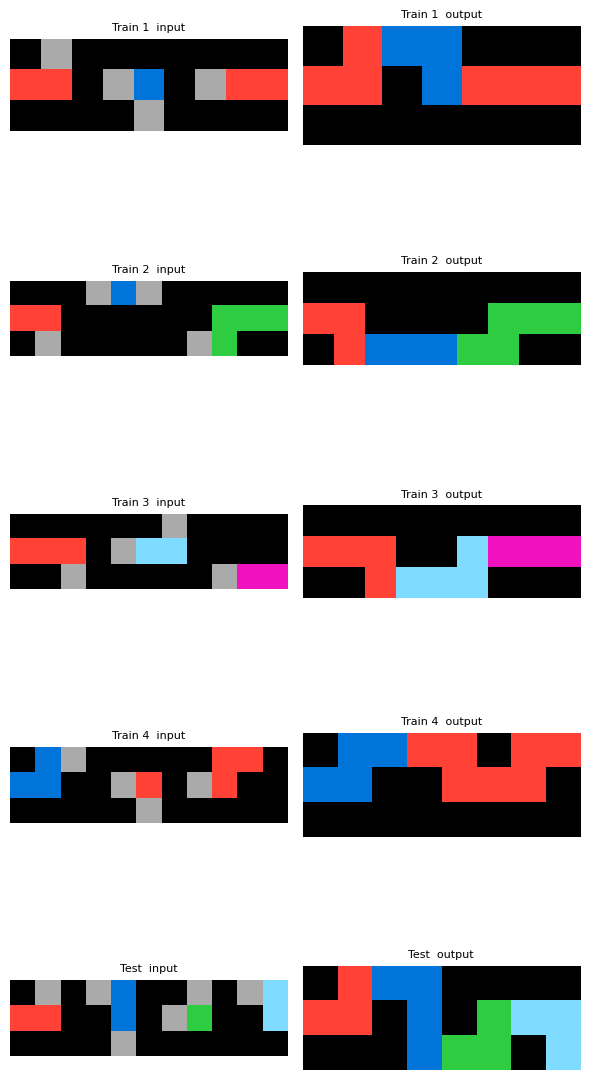

Output size:** Rows stay 3; columns = (max_col_with_5 - min_col_with_5 + 1)

**Core rule:** 
1. Identify all columns containing 5 across input
2. Define output width = max_col - min_col + 1
3. For output column i (mapped to input column min_col + i):
   - Extract non-5 values from the input span
   - Replace 5s with mirrored reflections of other values in that row
   - Values are arranged symmetrically around the center

**Additional rules:** 
- Non-5 values maintain relative order but are redistributed to fill the output symmetrically
- The transformation creates mirror-image patterns using non-5 values to fill where 5s were

**Summary:** Extract the region bounded by 5-markers, remove the 5s, and redistribute non-5 values symmetrically to create a mirrored pattern in the output.


──────────────────────────────────────────────────────────────
  3af2c5a8   (3 training pairs)
──────────────────────────────────────────────────────────────


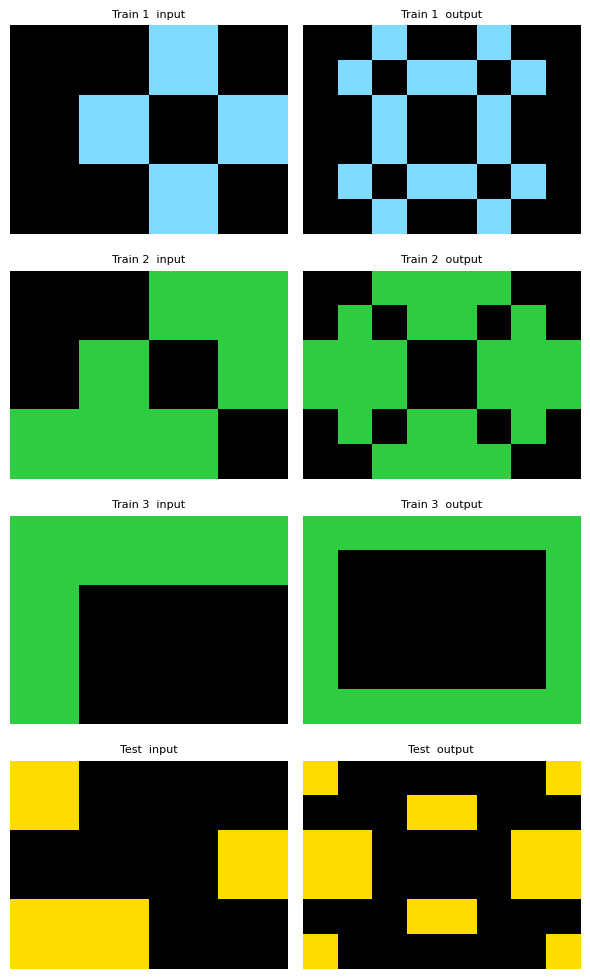

Output size:** The output is exactly 2 times the height and 2 times the width of the input. If input is H×W, output is 2H×2W.

**Core rule:** 
- For output cell at position (r, c):
  - If c < W (left half): output[r][c] = input[r mod H][c]
  - If c >= W (right half): output[r][c] = input[r mod H][W - 1 - (c - W)]
  - If r >= H (bottom half): output[r][c] = output[2H - 1 - r][c]

Where the first application creates a horizontally flipped pair, and the second creates vertical mirroring.

**Additional rules:** None

**Summary:** The input is reflected horizontally to create a double-width pattern, then this pattern is reflected vertically to create a double-height output, producing 4-fold symmetry.


──────────────────────────────────────────────────────────────
  3c9b0459   (4 training pairs)
──────────────────────────────────────────────────────────────


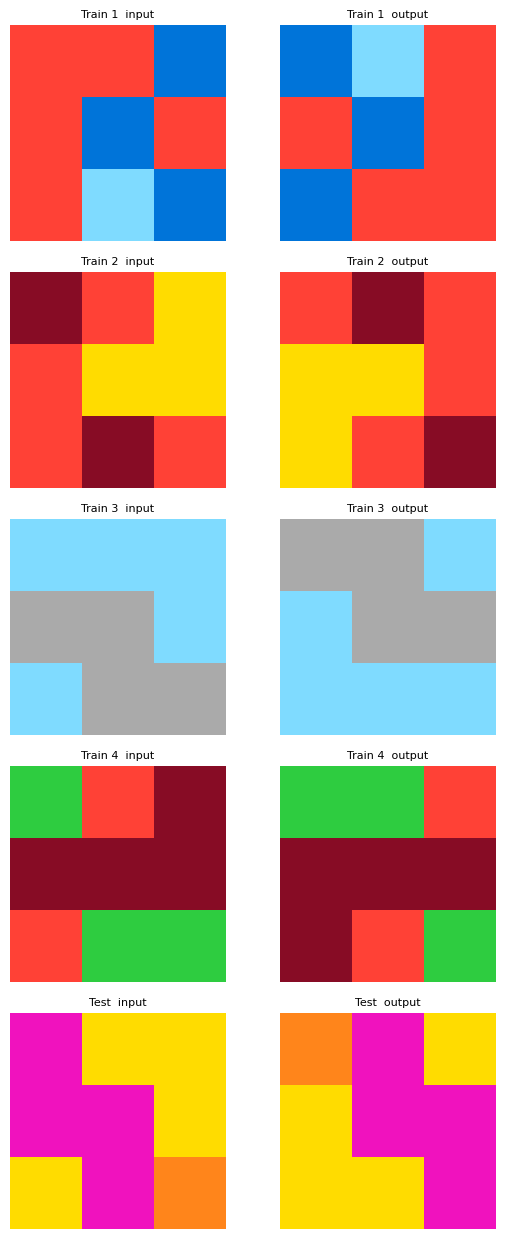

Output size: Same as input (3×3)

Core rule: For an input grid of size n×m, the output cell at position (i, j) equals the input cell at position (n-1-i, m-1-j). In other words, rotate the entire grid 180 degrees.

Additional rules: None

Summary: The transformation rotates the grid 180 degrees around its center.


──────────────────────────────────────────────────────────────
  46442a0e   (3 training pairs)
──────────────────────────────────────────────────────────────


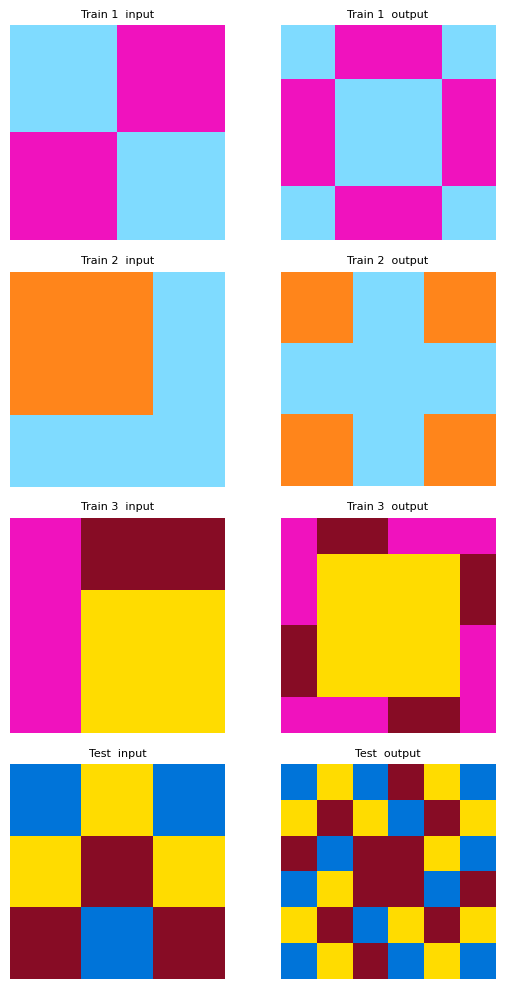

Output size: 2H × 2W (double the input dimensions)

Core rule: Tile the output with four quadrants:
1. Top-left: original input
2. Top-right: input horizontally flipped (columns reversed)
3. Bottom-left: input vertically flipped (rows reversed)
4. Bottom-right: input both horizontally AND vertically flipped (rows and columns both reversed)

Additional rules: None

Summary: The input grid is doubled in size by arranging four copies in a 2×2 layout: the original (top-left), its horizontal mirror (top-right), its vertical mirror (bottom-left), and its 180° rotation / full mirror (bottom-right). This creates a seamless symmetric tiling.


──────────────────────────────────────────────────────────────
  4c4377d9   (4 training pairs)
──────────────────────────────────────────────────────────────


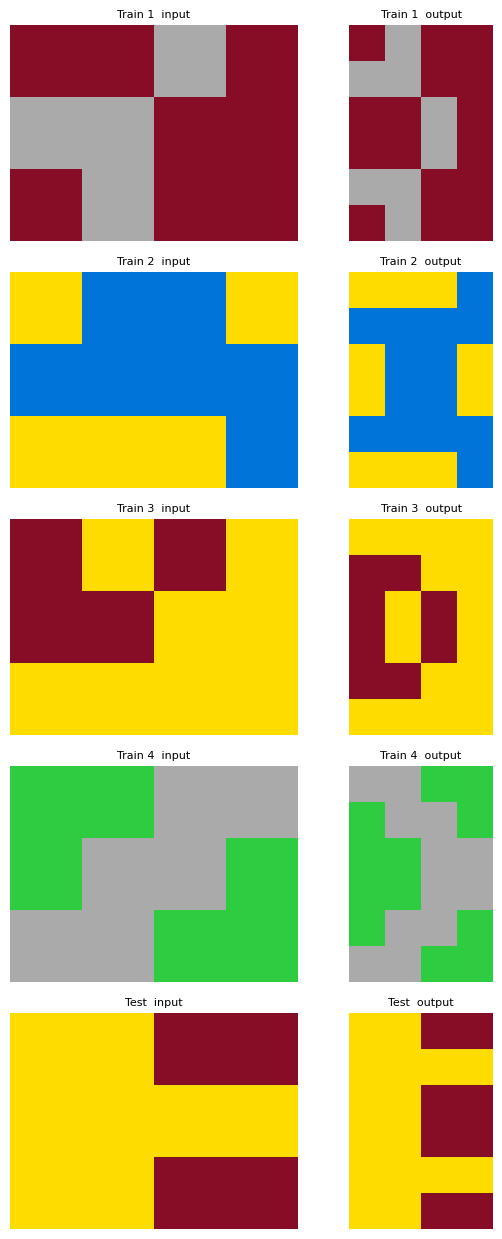

Output size: Double the height of the input (2H × W)

Core rule: Stack the vertically-flipped input on top of the original input. Output rows 0 to H-1 are input rows H-1, H-2, ..., 0 (reversed order). Output rows H to 2H-1 are input rows 0, 1, ..., H-1 (original order).

Additional rules: None — the width remains unchanged, and all cell values are copied exactly as they appear in the input.

Summary: The transformation creates a vertically symmetric output by concatenating the input reversed (bottom-to-top) above the input in its original order, doubling the height while preserving all values exactly.


──────────────────────────────────────────────────────────────
  539a4f51   (3 training pairs)
──────────────────────────────────────────────────────────────


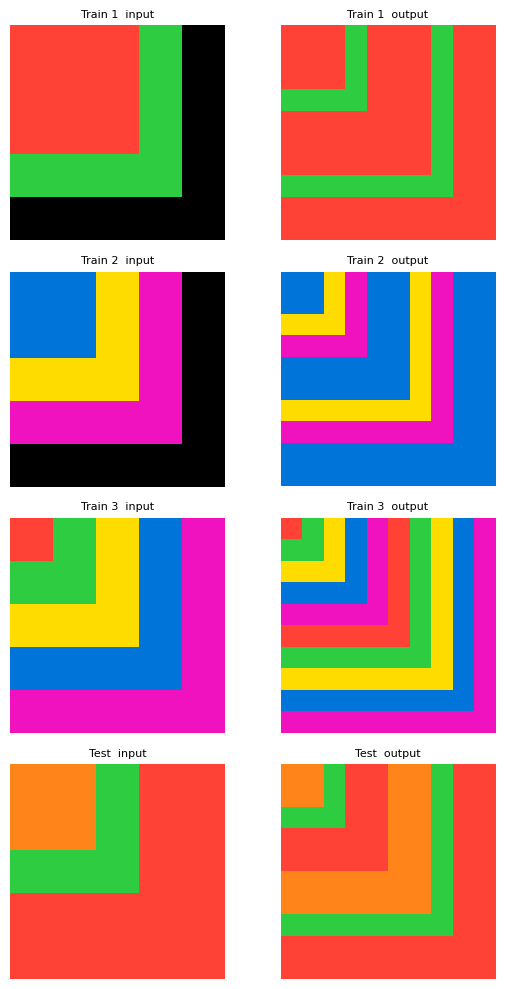

Output size: 10×10 (exactly double the input dimensions in both axes)

Core rule: The output is created by tiling the input horizontally in the top half (rows 0-4), then extending it in the bottom half (rows 5-9) where each row progressively fills from the left with its diagonal element value, maintaining the right-side columns with input patterns.

Additional rules: The transformation treats the input as a hierarchical/triangular structure where the bottom-right fills in by expanding diagonals leftward.

Summary: The 5×5 input is doubled to 10×10 by horizontally tiling it in the top half and extending a diagonal-fill pattern in the bottom half, where each row expands its leading diagonal value progressively leftward.


──────────────────────────────────────────────────────────────
  5bd6f4ac   (4 training pairs)
──────────────────────────────────────────────────────────────


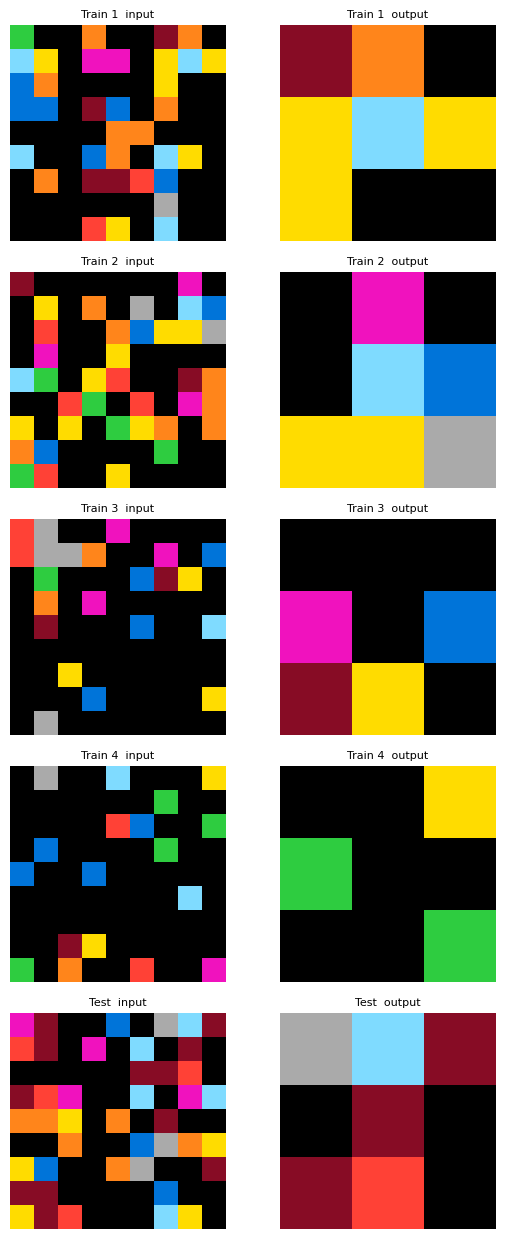

Output size:** 3×3 (extracted from the 9×9 input)

**Core rule:** Extract the 3×3 subgrid from the top-right corner of the 9×9 input grid. Specifically, extract rows 0-2 (0-indexed) and columns 6-8 from the input.

**Additional rules:** None

**Summary:** The transformation extracts the top-right 3×3 corner block from the 9×9 input grid.


──────────────────────────────────────────────────────────────
  6150a2bd   (2 training pairs)
──────────────────────────────────────────────────────────────


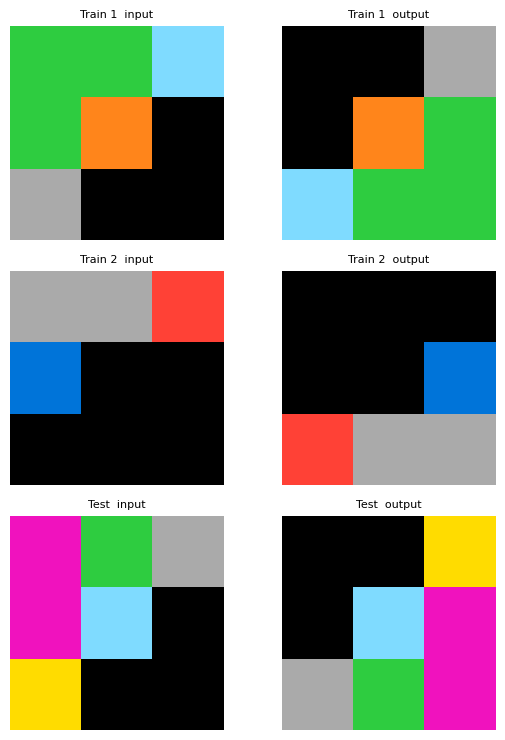

Output size:** Same as input (3×3)

**Core rule:** For each cell at position [row, col] in the input, place its value at position [rows-1-row, cols-1-col] in the output. Equivalently: Output[i,j] = Input[n-1-i, n-1-j] where n is the grid dimension.

**Additional rules:** None

**Summary:** The transformation is a 180-degree rotation of the grid around its center.


──────────────────────────────────────────────────────────────
  62c24649   (3 training pairs)
──────────────────────────────────────────────────────────────


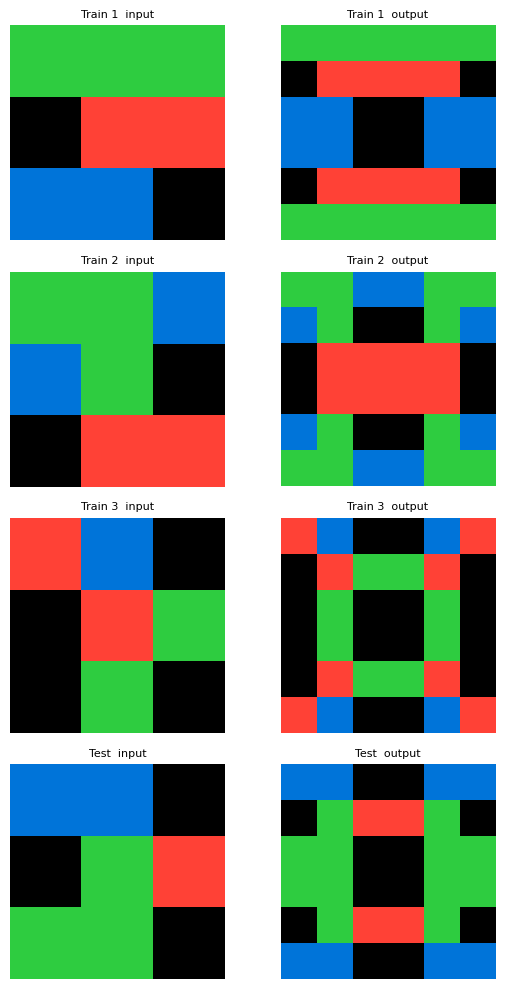

Output size: Input is 3×3, output is 6×6 (doubles both dimensions)

Core rule: 
1. Each input row is horizontally mirrored: row `[a, b, c]` becomes `[a, b, c, c, b, a]`
2. The resulting 3×6 grid is then vertically mirrored: rows are appended in reverse order (row 2, then row 1, then row 0)

**Output size:** The output is always 6×6, created from a 3×3 input (doubled in both dimensions)

**Core rule:** For each of the 3 input rows, create a 6-element row by concatenating the original row with its reverse (horizontal mirror). Then stack these 3 rows and append their vertical mirror (the rows in reverse order).

**Additional rules:** None

**Summary:** The 3×3 input is transformed into a 6×6 output by horizontally mirroring each row and then vertically mirroring the entire result.


──────────────────────────────────────────────────────────────
  67a3c6ac   (3 training pairs)
──────────────────────────────────────────────────────────────


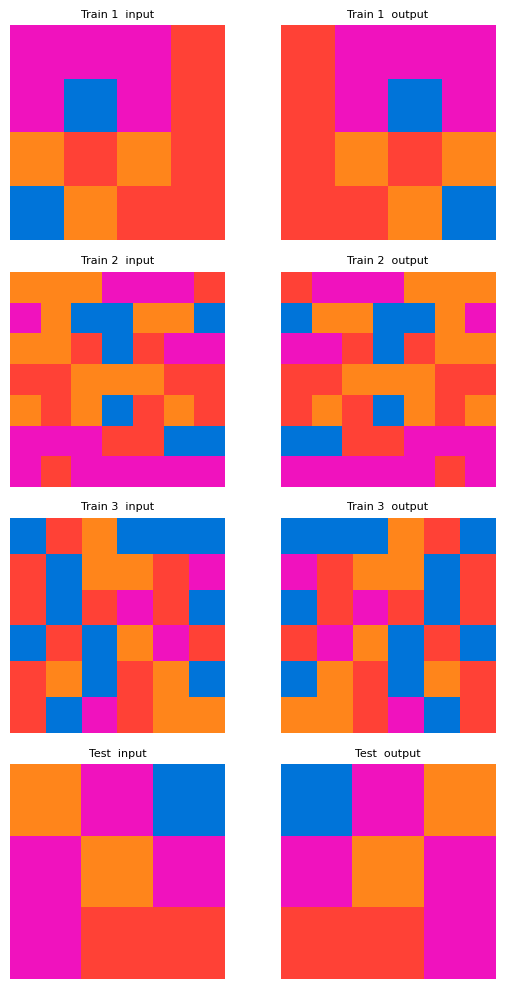

Output size: Same as input (M×N → M×N)

Core rule: For each cell at position (row, col) in the output, the value is taken from position (row, width-1-col) in the input. This creates a horizontal flip/mirror of each row.

Additional rules: None

Summary: Each row of the input grid is horizontally reversed (mirrored along the vertical axis).


──────────────────────────────────────────────────────────────
  67e8384a   (4 training pairs)
──────────────────────────────────────────────────────────────


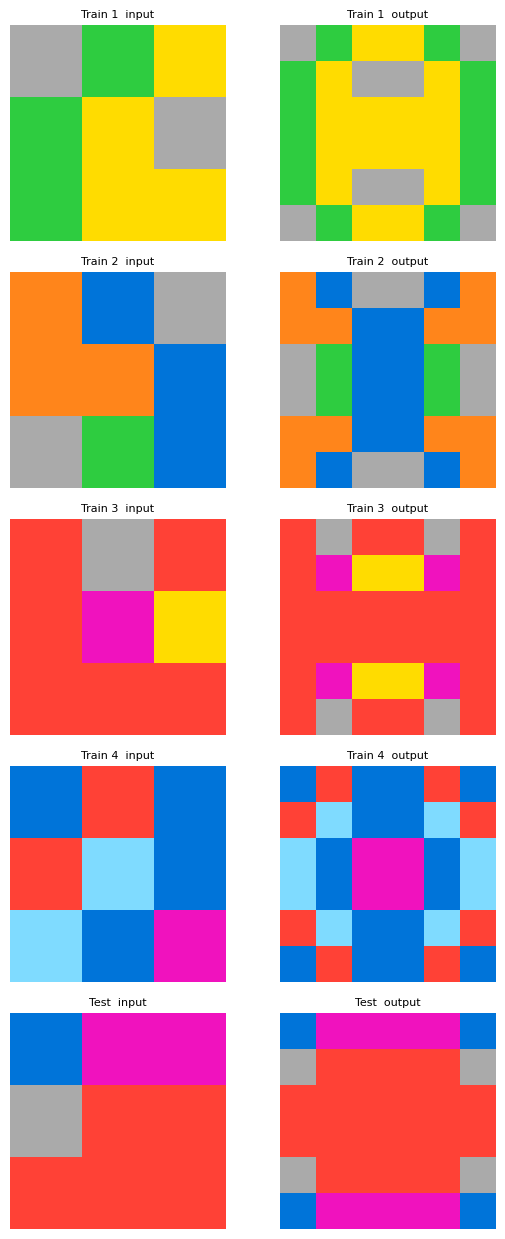

Output size: Input dimensions (3×3) are transformed to double both dimensions (6×6)

Core rule: 
1. For each row i in the input (0 to 2), create output row i by concatenating input[i] with the horizontal flip of input[i]
2. Create output rows 3-5 as vertical mirrors of output rows 2-0 respectively (i.e., output[3] = output[2], output[4] = output[1], output[5] = output[0])

Additional rules: None

Summary: The transformation creates a 6×6 grid by horizontally mirroring each input row and then vertically mirroring the resulting 3×6 block.


──────────────────────────────────────────────────────────────
  68b16354   (3 training pairs)
──────────────────────────────────────────────────────────────


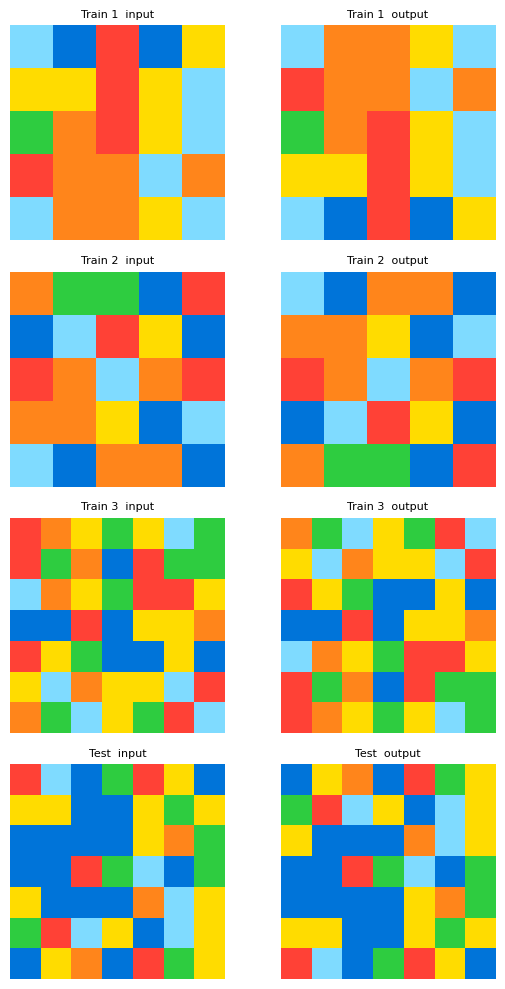

Output size: Same as input (M×N)

Core rule: The output is the input grid flipped vertically — the row order is reversed. Output row i equals input row (M-1-i), where M is the number of rows. Column order is unchanged.

Additional rules: None. The transformation applies uniformly to all rows and columns.

Summary: Reverse the order of rows while keeping each row's content identical. The first row of the output is the last row of the input, the second row of the output is the second-to-last row of the input, and so on. This is a pure vertical flip with no other modifications.


──────────────────────────────────────────────────────────────
  6d0aefbc   (4 training pairs)
──────────────────────────────────────────────────────────────


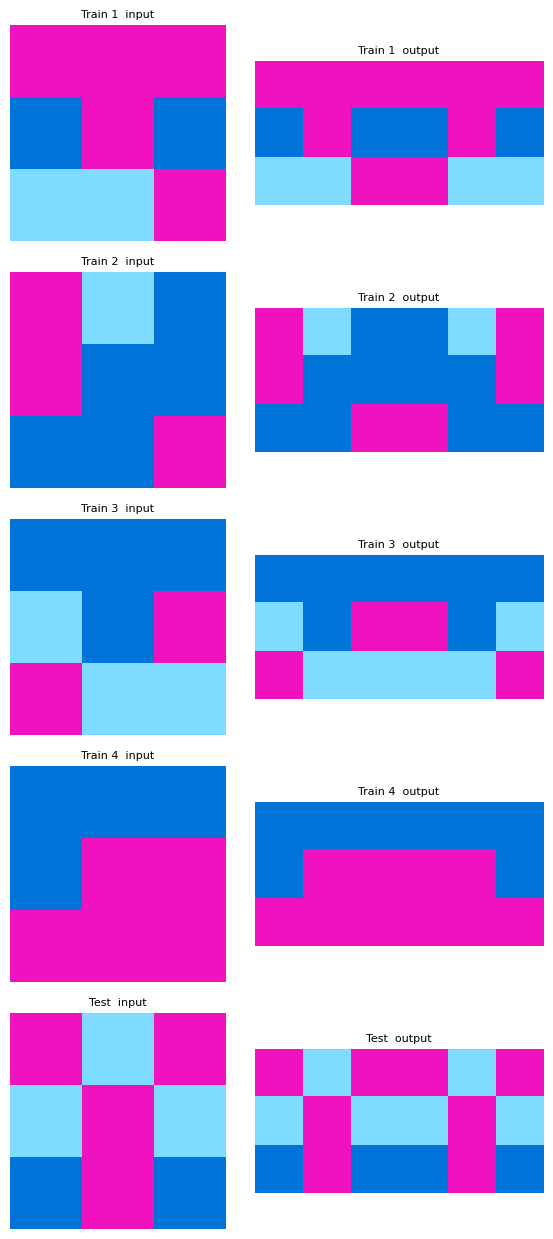

Output size: 3 rows × 6 columns

Core rule: For each row in the input, the output row is the input row concatenated with its own reversal. For row [a, b, c], output is [a, b, c, c, b, a].

Additional rules: Rows maintain their original order (row 0 → row 0, row 1 → row 1, row 2 → row 2). No vertical reordering occurs.

Summary: Each row of the 3×3 input is horizontally mirrored and appended to itself to create a 3×6 output. Row [a, b, c] becomes [a, b, c, c, b, a]. The row order is preserved exactly as in the input.


──────────────────────────────────────────────────────────────
  6fa7a44f   (4 training pairs)
──────────────────────────────────────────────────────────────


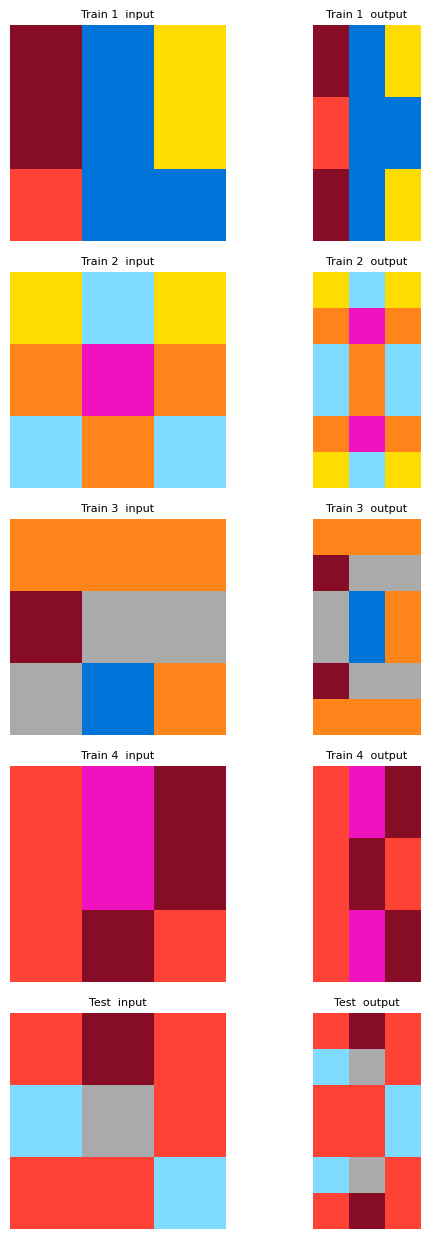

Output size: 6 rows × 3 columns (double the input height, same width)

Core rule: The output consists of the original input rows (top half) followed by the input rows in reverse vertical order (bottom half). No horizontal transformation is applied — each row's column values remain identical to the original.

Additional rules: 
- Row i (for i < h) = input row i (unchanged)
- Row h+i (for i < h) = input row (h-1-i) (unchanged, just reversed row order)
- Individual row contents are never modified or flipped

Summary: Stack the original input on top of its vertically-mirrored copy. Only row order is reversed for the bottom half; the values within each row stay in their original left-to-right order.


──────────────────────────────────────────────────────────────
  74dd1130   (4 training pairs)
──────────────────────────────────────────────────────────────


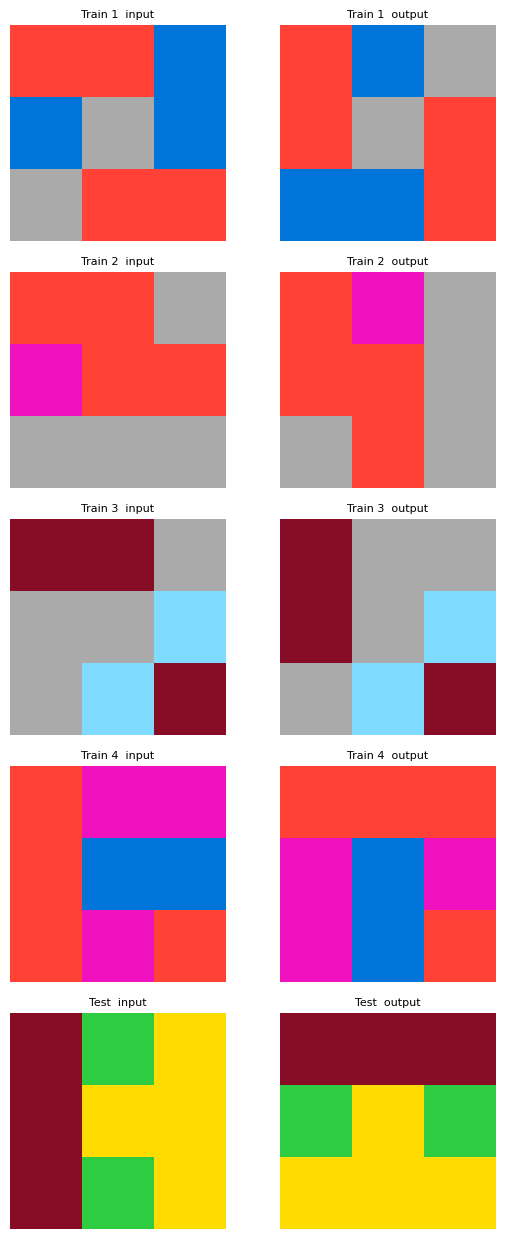

Output size: Same as input (3×3)

Core rule: Transpose the matrix along the main diagonal: output[i][j] = input[j][i]

Additional rules: None needed. The grid dimensions remain unchanged.

Summary: The transformation is a standard matrix transpose — reflect the grid across its main diagonal, swapping rows and columns so that what was row i becomes column i. This is confirmed across all four training pairs.


──────────────────────────────────────────────────────────────
  7fe24cdd   (3 training pairs)
──────────────────────────────────────────────────────────────


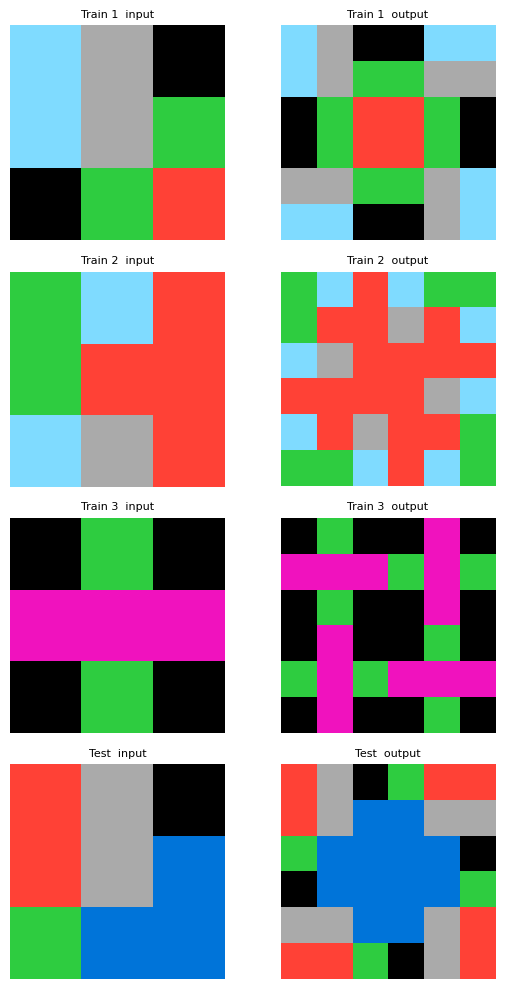

Output size:** 6×6 (input is 3×3)

**Core rule:** The 6×6 output is composed of four 3×3 quadrants. For input cell (r,c), the four quadrants place:
- Top-left [r,c]: input[r,c]
- Top-right [r,3+c]: input[r,2-c]
- Bottom-left [3+r,c]: input[2-r,c]
- Bottom-right [3+r,3+c]: input[2-r,2-c]

**Additional rules:** None

**Summary:** The input 3×3 grid is expanded to 6×6 by placing the original in the top-left, horizontal flip in top-right, vertical flip in bottom-left, and 180° rotation in bottom-right.


──────────────────────────────────────────────────────────────
  8be77c9e   (3 training pairs)
──────────────────────────────────────────────────────────────


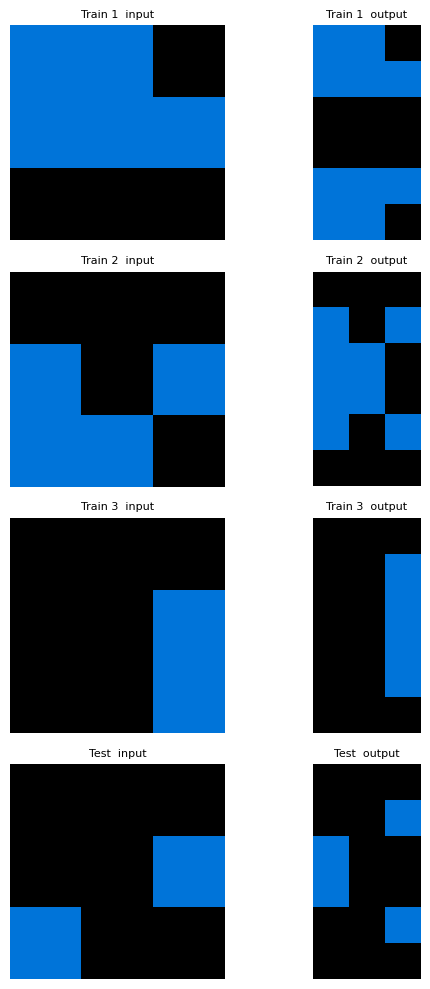

Output size:** 
The output height is 2 × input height (6 rows from 3 rows input). Width remains unchanged (3 columns).

**Core rule:**
For a 3×3 input grid with rows R₁, R₂, R₃:
- Output rows 0-2: R₁, R₂, R₃ (original)
- Output rows 3-5: R₃, R₂, R₁ (rows in reverse order)

More generally: concatenate the input grid with its vertical mirror (flip rows).

**Additional rules:** 
None

**Summary:**
The transformation doubles the grid height by appending a vertically flipped copy of the input below the original grid.


──────────────────────────────────────────────────────────────
  93b581b8   (3 training pairs)
──────────────────────────────────────────────────────────────


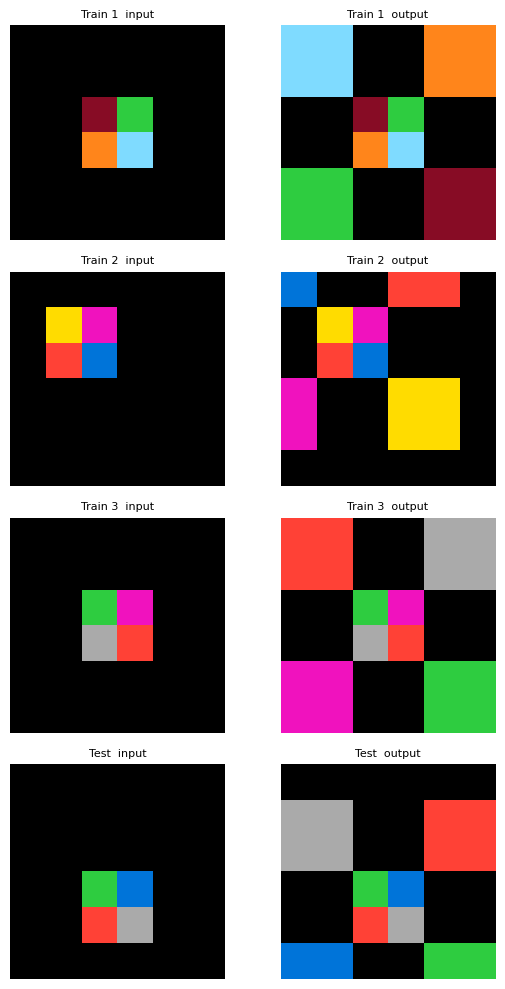

Output size:** Same as input (6×6)

**Core rule:** For a 2×2 block found at rows [r, r+1] and columns [c, c+1] containing values arranged as:
```
TL TR
BL BR
```
Create 2×2 blocks at the four corners of the 6×6 grid:
- Rows [0,1], Cols [0,1]: filled with BR
- Rows [0,1], Cols [4,5]: filled with BL
- Rows [4,5], Cols [0,1]: filled with TR
- Rows [4,5], Cols [4,5]: filled with TL
Keep the original 2×2 block unchanged.

**Additional rules:** None

**Summary:** The transformation takes the 2×2 non-zero block, rotates it 180° conceptually, and tiles the four quadrants to the corners of the grid while preserving the original block.


──────────────────────────────────────────────────────────────
  9ecd008a   (3 training pairs)
──────────────────────────────────────────────────────────────


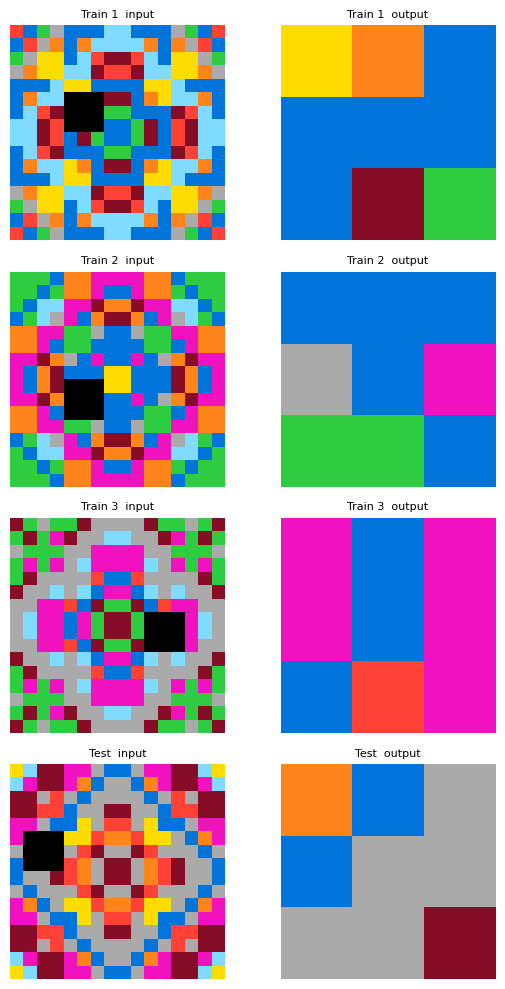

Output size:** 3×3

**Core rule:** Find the 3×3 block of zeros. Reflect its position horizontally across the grid's vertical center axis (column 7.5 in a 16-wide grid) to get the mirror column position. Extract the 3×3 values at the same rows but mirrored columns. Then mirror that extracted block horizontally (reverse each row).

**Additional rules:** The grid is 16×16. Zero block columns C to C+2 map to mirror columns (15-C-2) to (15-C) = (13-C) to (15-C). Extract that 3×3, then flip it horizontally.


──────────────────────────────────────────────────────────────
  a416b8f3   (3 training pairs)
──────────────────────────────────────────────────────────────


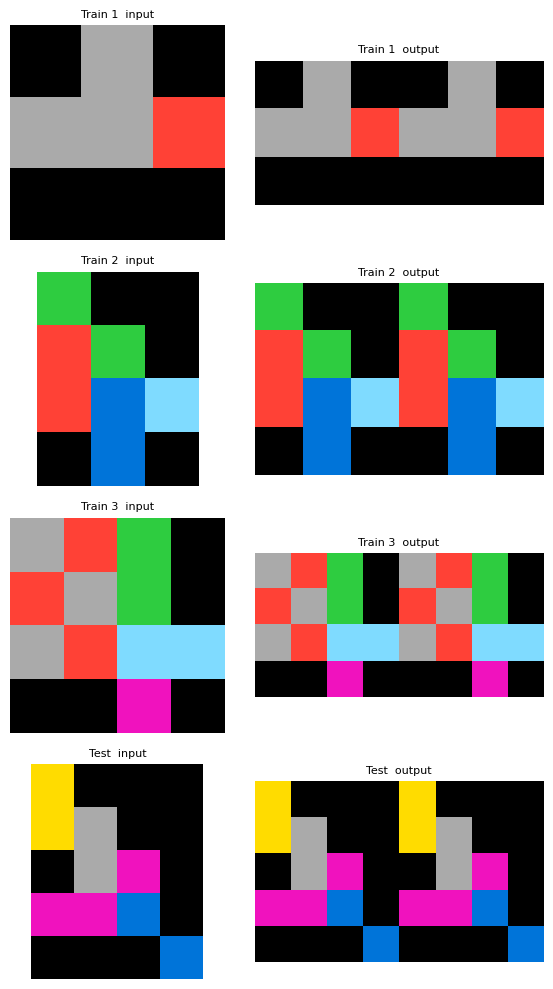

## Output size: 
The output height equals the input height. The output width equals twice the input width.

## Core rule:
Each row of the input grid is duplicated horizontally (concatenated with itself) to create the output row.

Formally: If the input is an H×W grid, the output is an H×(2W) grid where output[row][col] = input[row][col mod W] for all rows and columns.

Alternatively stated: output[row] = input[row] + input[row] (horizontal concatenation of each input row with itself).

## Additional rules:
None

## Summary:
The transformation horizontally duplicates each row by concatenating it with itself, effectively mirroring the entire grid to its right.


──────────────────────────────────────────────────────────────
  c9e6f938   (3 training pairs)
──────────────────────────────────────────────────────────────


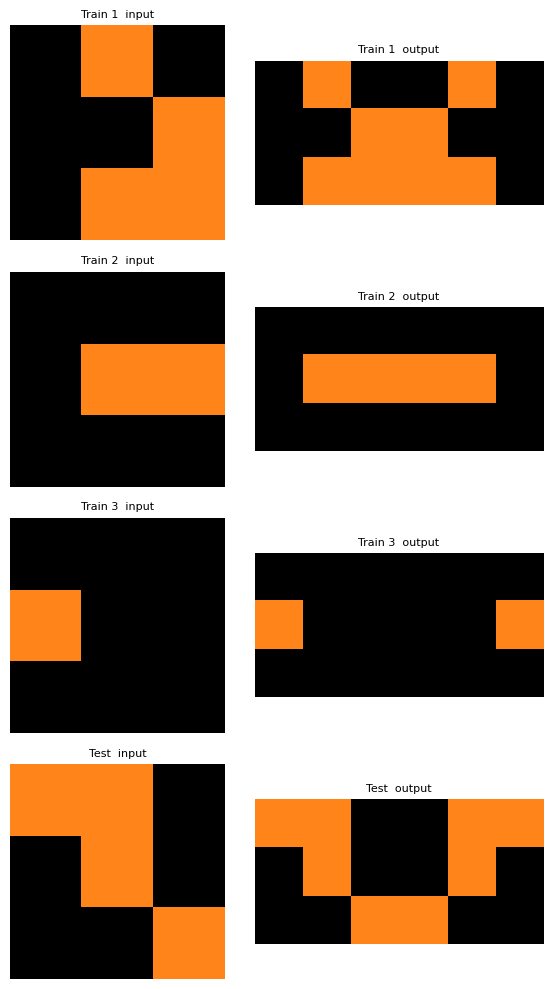

Output size:** The output width is double the input width (3→6). Height remains the same (3→3).

**Core rule:** For each row in the input, horizontally flip that row and concatenate it to the right of the original row. Specifically, for output cell at position (row, col):
- If col < 3: output[row][col] = input[row][col]
- If col ≥ 3: output[row][col] = input[row][5-col]

**Additional rules:** None

**Summary:** The transformation creates a horizontally symmetric output by concatenating each input row with its horizontal mirror image.


──────────────────────────────────────────────────────────────
  d10ecb37   (3 training pairs)
──────────────────────────────────────────────────────────────


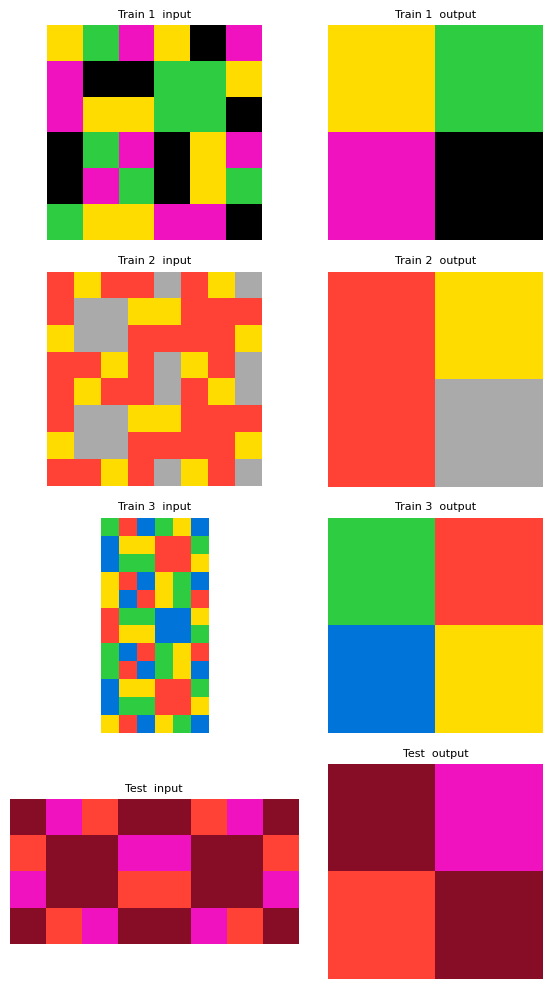

Output size:** 2×2 (fixed)

**Core rule:** Extract the top-left 2×2 subgrid from the input grid. The output cell at position (i, j) equals the input cell at position (i, j) where i ∈ {0, 1} and j ∈ {0, 1}.

**Additional rules:** None

**Summary:** The transformation extracts the top-left 2×2 corner of the input grid as the output.


──────────────────────────────────────────────────────────────
  dc0a314f   (3 training pairs)
──────────────────────────────────────────────────────────────


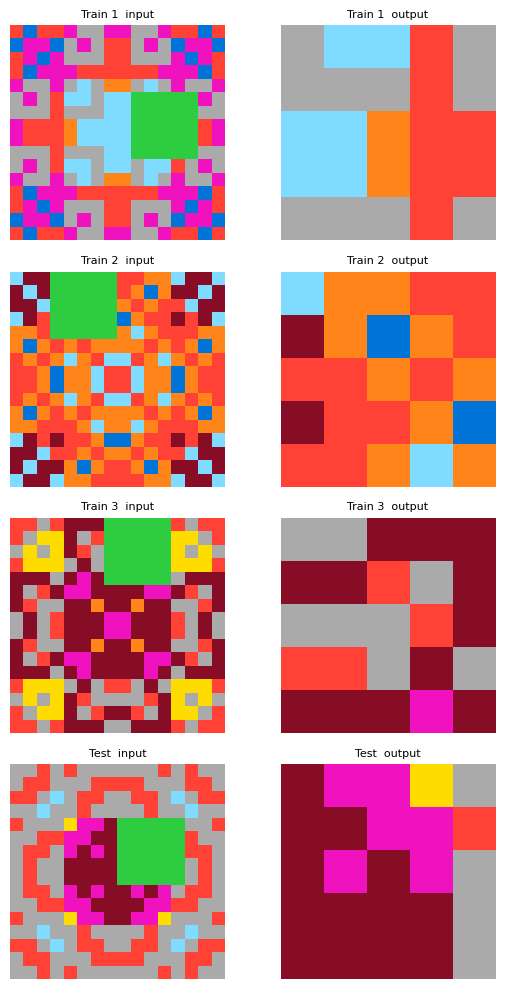

Output size:** 5×5 (always)

**Core rule:** 
1. Locate the rectangular block of 3s in the input grid
2. The output is the 5×5 region immediately to the left of this 3s block
3. Specifically, if the 3s occupy columns [c_start to c_end] and rows [r_start to r_end], extract columns [c_start-5 to c_start-1] and rows [r_start to r_end]

**Additional rules:** The 3s always form a 5×5 (or similar rectangular) contiguous block. The extraction takes the region with the same height as the 3s block, positioned directly to its left.

**Summary:** Extract the 5×5 region of the input grid that is immediately adjacent to the left of the rectangular block marked by 3s.


──────────────────────────────────────────────────────────────
  ed36ccf7   (4 training pairs)
──────────────────────────────────────────────────────────────


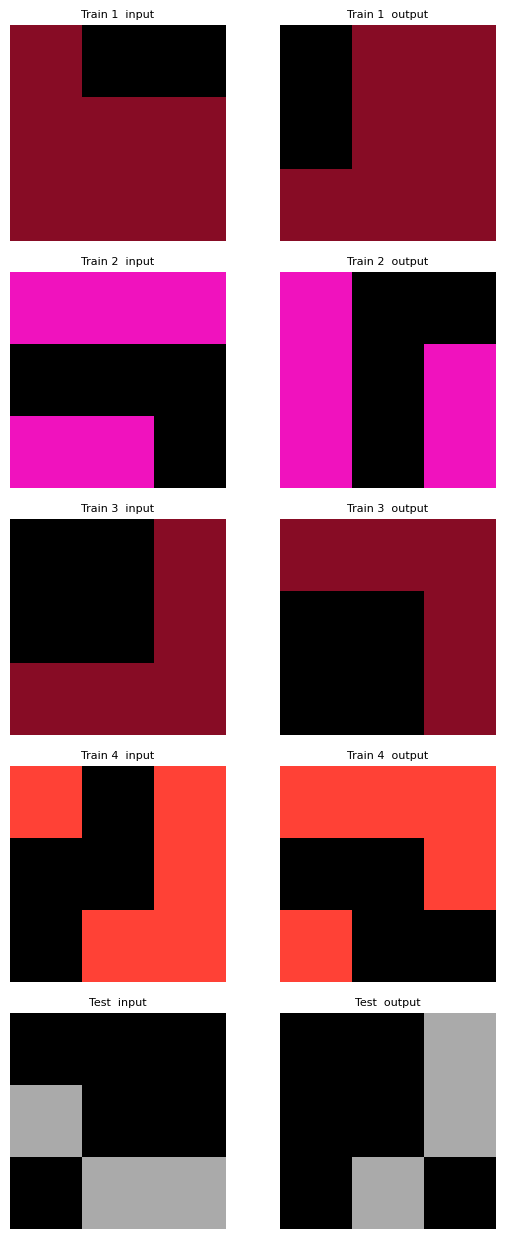

Output size: Same as input (3×3)

Core rule: Rotate the grid 90 degrees counterclockwise. For each output cell at position (i, j), take the value from input position (j, n-1-i), where n=3.



In [4]:
def show_grid(ax, grid, title):
    ax.imshow(np.array(grid), cmap=CMAP, norm=NORM, interpolation='nearest')
    ax.set_title(title, fontsize=8)
    ax.axis('off')


for tid in task_ids:
    if tid not in tasks:
        print(f'── {tid}  (file not found) ──')
        continue

    task  = tasks[tid]
    pairs = task['train']
    test  = task['test'][0]

    n_rows = len(pairs) + 1   # train pairs + test row

    print(f"\n{'─'*62}")
    print(f'  {tid}   ({len(pairs)} training pairs)')
    print(f"{'─'*62}")

    fig, axes = plt.subplots(n_rows, 2, figsize=(6, 2.5 * n_rows), squeeze=False)

    for i, pair in enumerate(pairs):
        show_grid(axes[i, 0], pair['input'],  f'Train {i+1}  input')
        show_grid(axes[i, 1], pair['output'], f'Train {i+1}  output')

    show_grid(axes[-1, 0], test['input'], 'Test  input')
    if 'output' in test:
        show_grid(axes[-1, 1], test['output'], 'Test  output')
    else:
        axes[-1, 1].axis('off')
        axes[-1, 1].set_title('Test output (hidden)', fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── LLM description ───────────────────────────────────────────────
    print('LLM description:')
    for line in task_desc[tid].splitlines():
        print(f'  {line}')

    # ── Human description ─────────────────────────────────────────────
    print()
    if tid in human_descs:
        print('Your description:')
        for line in human_descs[tid]['description'].splitlines():
            print(f'  {line}')
    else:
        print('Your description:  — not yet annotated —')

    print()
